<a href="https://colab.research.google.com/github/G4mePlay03/MLS_CARLA_fundamentals/blob/main/carla_lora_classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*This notebook was created with Github Copilot and managed by the Author*
# CARLA Binary Classifiers with LoRA Fine-Tuned ResNet-18

This notebook trains **three independent binary classifiers** on forward-facing CARLA camera images:
- 🚶 **Pedestrian Detector** (`has_pedestrian`)
- 🚦 **Traffic-Light Detector** (`has_traffic_light`)
- 🚗 **Vehicle Detector** (`has_vehicle`)

Each classifier is a **ResNet-18** backbone with **LoRA (Low-Rank Adaptation)** applied to its linear and convolutional layers so that only a small set of trainable parameters is added while the pre-trained weights stay frozen.

**How to use:**
1. Upload your dataset to Google Drive so the path `MyDrive/carnomaly/dataset/train/` contains the numbered images and `MyDrive/carnomaly/labels.csv` contains the label file.
2. Run all cells top-to-bottom in Google Colab (Runtime → Run all).
3. Trained weights are saved back to `MyDrive/carnomaly/weights/`.

**Runtime:** Set *Runtime → Change runtime type → GPU* (T4 or better) for fast training.

## 1 — Install dependencies

In [1]:
# Install all required packages.
# loralib  → lightweight LoRA primitives for PyTorch
# safetensors → safe, fast weight serialization format
# scikit-learn → precision / recall / F1 helpers
%pip install -q loralib safetensors scikit-learn

## 2 — Mount Google Drive

In [2]:
from google.colab import drive
import os

# Check if Google Drive is already mounted
if not os.path.exists('/content/drive/'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive/')
else:
    print("Google Drive is already mounted.")

Mounting Google Drive...
Mounted at /content/drive/


## 3 — Imports & global settings

In [3]:
import os
import copy
import math
import time

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

import loralib as lora
from safetensors.torch import save_file, load_file

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda
  GPU: Tesla T4
  Memory: 15.6 GB


## 4 — Configuration

Edit the paths and hyper-parameters in this single cell.

In [4]:
# ── Paths ────────────────────────────────────────────────────────────────────
DRIVE_BASE   = '/content/drive/MyDrive/Colab Notebooks/data'
IMAGES_DIR   = os.path.join(DRIVE_BASE, 'train', 'train', 'rgb-front')
LABELS_CSV   = os.path.join(DRIVE_BASE, 'train', 'train', 'labels.csv')
WEIGHTS_DIR  = os.path.join(DRIVE_BASE, 'weights')
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# ── Dataset split ────────────────────────────────────────────────────────────
VAL_FRACTION  = 0.15   # 15 % of data used for validation
TEST_FRACTION = 0.10   # 10 % of data used for final test

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_EPOCHS  = 15
LR          = 3e-4    # learning rate for LoRA params + classifier head
WEIGHT_DECAY = 1e-4

# ── LoRA ─────────────────────────────────────────────────────────────────────
LORA_RANK    = 8      # rank of the low-rank decomposition
LORA_ALPHA   = 16     # scaling factor; effective lr ∝ alpha/rank
LORA_DROPOUT = 0.05

# ── Task names (column names in labels.csv) ───────────────────────────────────
TASKS = [
    'has_pedestrian',
    'has_traffic_light',
    'has_vehicle',
]

print('Configuration loaded.')
print(f'  Images : {IMAGES_DIR}')
print(f'  Labels : {LABELS_CSV}')
print(f'  Weights: {WEIGHTS_DIR}')

Configuration loaded.
  Images : /content/drive/MyDrive/Colab Notebooks/data/train/train/rgb-front
  Labels : /content/drive/MyDrive/Colab Notebooks/data/train/train/labels.csv
  Weights: /content/drive/MyDrive/Colab Notebooks/data/weights


## 5 — Dataset

In [5]:
# ── Image transforms ─────────────────────────────────────────────────────────
# ImageNet mean/std used because the ResNet-18 backbone was pre-trained on ImageNet.
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=_MEAN, std=_STD),
])

eval_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=_MEAN, std=_STD),
])


class CARLADataset(Dataset):
    """Dataset for CARLA forward-facing camera images.

    Args:
        images_dir  : directory containing the numbered frame images.
        labels_csv  : path to the CSV file with columns
                      frame, has_traffic_light, has_pedestrian, has_vehicle, …
        task        : one of 'has_pedestrian', 'has_traffic_light', 'has_vehicle'.
        transform   : torchvision transform to apply to each image.
    """

    _IMG_EXTENSIONS = ['.png', '.jpg', '.jpeg', '.bmp']

    def __init__(self, images_dir: str, labels_csv: str, task: str,
                 transform=None):
        self.images_dir = images_dir
        self.task       = task
        self.transform  = transform

        df = pd.read_csv(labels_csv)
        # Normalize column names (strip whitespace)
        df.columns = df.columns.str.strip()

        required = {'frame', task}
        missing  = required - set(df.columns)
        if missing:
            raise ValueError(f'labels.csv is missing columns: {missing}')

        # Resolve image paths: the frame column may hold just the integer index
        # (e.g. 0, 1, 2) or a filename (e.g. "0.png").
        self.samples = []
        for _, row in df.iterrows():
            frame_val = str(row['frame']).strip()
            img_path  = self._resolve_path(frame_val)
            if img_path is None:
                continue   # silently skip missing images
            label = int(row[task])
            self.samples.append((img_path, label))

        if len(self.samples) == 0:
            raise RuntimeError(
                f'No valid samples found.  '
                f'Check that {images_dir} contains the frame images.'
            )

        pos = sum(l for _, l in self.samples)
        print(f'[{task}] {len(self.samples)} samples  '
              f'| pos={pos} ({100*pos/len(self.samples):.1f}%)  '
              f'| neg={len(self.samples)-pos}')

    def _resolve_path(self, frame_val: str):
        """Return the full image path for a frame identifier, or None."""
        # First, try to interpret frame_val as a zero-padded integer index for a .jpg file
        try:
            int_frame_val = int(frame_val)
            # Assuming 6-digit zero-padded filenames like 000000.jpg
            formatted_frame_val = f'{int_frame_val:06d}'
            candidate = os.path.join(self.images_dir, formatted_frame_val + '.jpg')
            if os.path.isfile(candidate):
                return candidate
        except ValueError:
            # frame_val is not an integer, fall through to original logic
            pass

        # Fallback to original logic: frame_val is already a filename or basename
        # 1. Maybe frame_val is already a filename with extension.
        candidate = os.path.join(self.images_dir, frame_val)
        if os.path.isfile(candidate):
            return candidate
        # 2. Try appending common extensions.
        for ext in self._IMG_EXTENSIONS:
            candidate = os.path.join(self.images_dir, frame_val + ext)
            if os.path.isfile(candidate):
                return candidate
        return None

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)


def make_dataloaders(task: str):
    """Split the full dataset into train / val / test DataLoaders."""
    full_dataset = CARLADataset(
        IMAGES_DIR, LABELS_CSV, task, transform=eval_transform
    )
    n_total = len(full_dataset)
    n_test  = max(1, int(n_total * TEST_FRACTION))
    n_val   = max(1, int(n_total * VAL_FRACTION))
    n_train = n_total - n_val - n_test

    train_ds, val_ds, test_ds = random_split(
        full_dataset,
        [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(SEED),
    )

    # Apply augmentation only to the training subset
    train_ds.dataset = copy.copy(full_dataset)
    train_ds.dataset.transform = train_transform

    loaders = {
        'train': DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=2, pin_memory=True),
        'val'  : DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True),
        'test' : DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True),
    }
    print(f'  Split  → train={n_train}  val={n_val}  test={n_test}')
    return loaders


print('Dataset helpers defined.')

Dataset helpers defined.


## 6 — LoRA-ResNet-18 Model

In [6]:
def build_lora_resnet18(task_name: str,
                        lora_rank: int    = LORA_RANK,
                        lora_alpha: int   = LORA_ALPHA,
                        lora_dropout: float = LORA_DROPOUT) -> nn.Module:
    """Build a ResNet-18 binary classifier with LoRA adapters.

    Strategy
    --------
    * Load the official ImageNet-pre-trained ResNet-18 weights.
    * Freeze *all* original parameters.
    * Replace the final FC layer with a ``loralib.Linear`` layer
      (rank=lora_rank) that outputs 2 logits (binary CE loss).
    * Additionally add LoRA adapters to the last residual block's
      convolutional layers so the model can adapt image features
      beyond the head.
    * Only the LoRA delta-weight matrices (A, B) and the new head
      bias are trained; everything else stays frozen.

    Returns the model placed on DEVICE.
    """
    # ── 1. Load pre-trained backbone ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    # ── 2. Freeze all existing parameters ━━━━━━━━━━━━━━━━━━━
    for param in backbone.parameters():
        param.requires_grad = False

    # ── 3. Add LoRA to the last residual block (layer4) ━━━━━━━━━━━━━━━
    # We patch every nn.Conv2d inside layer4 with a lora.Conv2d that keeps
    # the original kernel but adds low-rank side-branches.
    for name, module in list(backbone.layer4.named_modules()):
        if isinstance(module, nn.Conv2d):
            # Walk the attribute path to replace the module in-place
            parts  = name.split('.')
            parent = backbone.layer4
            for part in parts[:-1]:
                parent = getattr(parent, part)
            old_conv = getattr(parent, parts[-1])

            # Extract integer values for kernel_size, stride, padding
            # from potentially tuple values (e.g., (3, 3) -> 3)
            kernel_size_val = old_conv.kernel_size[0] if isinstance(old_conv.kernel_size, tuple) else old_conv.kernel_size
            stride_val      = old_conv.stride[0] if isinstance(old_conv.stride, tuple) else old_conv.stride
            padding_val     = old_conv.padding[0] if isinstance(old_conv.padding, tuple) else old_conv.padding

            new_conv = lora.Conv2d(
                in_channels  = old_conv.in_channels,
                out_channels = old_conv.out_channels,
                kernel_size  = kernel_size_val,
                r            = lora_rank,
                lora_alpha   = lora_alpha,
                stride       = stride_val,
                padding      = padding_val,
                bias         = old_conv.bias is not None,
                merge_weights = False # Setting to False to allow copying pre-trained weights to base_weight
            )
            # Copy pre-trained weights into the LoRA conv's base_weight
            with torch.no_grad():
                new_conv.base_weight.copy_(old_conv.weight)
                if old_conv.bias is not None:
                    new_conv.bias.copy_(old_conv.bias)
            # Freeze the base weight; LoRA matrices remain trainable
            new_conv.base_weight.requires_grad = False
            if new_conv.bias is not None:
                new_conv.bias.requires_grad = False
            setattr(parent, parts[-1], new_conv)

    # ── 4. Replace the classifier head with a LoRA Linear layer ━━━━━━━━━━━
    in_features = backbone.fc.in_features   # 512 for ResNet-18
    backbone.fc = lora.Linear(
        in_features  = in_features,
        out_features = 2,          # binary: class 0 or class 1
        r            = lora_rank,
        lora_alpha   = lora_alpha,
        lora_dropout = lora_dropout,
        merge_weights = False,     # keep A/B separate during training
    )

    # ── 5. Mark only LoRA parameters as trainable ━━━━━━━━━━━━━━━━━━━
    lora.mark_only_lora_as_trainable(backbone)

    # ── 6. Summary ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    total_params    = sum(p.numel() for p in backbone.parameters())
    trainable_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
    print(f'[{task_name}] Model built.')
    print(f'  Total params    : {total_params:,}')
    print(f'  Trainable params: {trainable_params:,}  '
          f'({100*trainable_params/total_params:.2f}%)')

    return backbone.to(DEVICE)

print('Model builder defined.')

Model builder defined.


### 6b — Simplified Visual CNN (ResNet-18 Fine-tuning)
For the purpose of this demo, we will use standard fine-tuning. This is easier to visualize: we take a pre-trained 'feature extractor' and attach a new 'classifier' head.

In [7]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

def build_simple_resnet18(task_name: str):
    # 1. Load pre-trained ResNet18
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    # 2. Freeze all layers (Feature Extractor)
    for param in model.parameters():
        param.requires_grad = False

    # 3. Replace the 'fc' (Fully Connected) layer with a new one for our task
    # ResNet18 final layer is (512, 1000). We change it to (512, 2)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)

    return model.to(DEVICE)

# Update the training reference to use this simpler model if desired
# build_lora_resnet18 = build_simple_resnet18

print("Simplified Model Builder defined.")

Simplified Model Builder defined.


In [8]:
from torchsummary import summary

temp_model = build_simple_resnet18("demo")
print(f"Architecture for {DEVICE}:")
try:
    summary(temp_model, (3, 224, 224))
except:
    print(temp_model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


Architecture for cuda:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReL

## 7 — Training & Evaluation Utilities

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, List
from time import perf_counter
import IPython.display as display_ipy

# Import scikit-learn metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

class EarlyStopping:
    def __init__(self, model: nn.Module, patience: int, direction: str = "min", min_delta: float = 0.0001, verbose: bool = False):
        if direction not in ["min", "max"]:
            raise ValueError(f"direction should be 'min' or 'max', you passed {direction}")
        self.best_state_dict = {key: None for key in model.state_dict()}
        self.best_value = np.inf if direction == "min" else -np.inf
        self.direction = direction
        self.min_delta = min_delta
        self.model = model
        self.patience = patience
        self.disappointment = 0
        self.verbose = verbose

    def update(self, value: torch.tensor) -> bool:
        if ((self.direction == "min" and value < self.best_value - self.min_delta)
            or (self.direction == "max" and value > self.best_value + self.min_delta)):
            self.best_value = value
            for key in self.model.state_dict():
                self.best_state_dict[key] = self.model.state_dict()[key].clone()
            self.disappointment = 0
            if self.verbose: print("New best value found; no longer disappointed")
            return False
        else:
            self.disappointment += 1
            if self.verbose: print(f"EarlyStopping disappointment increased to {self.disappointment}")
            if self.disappointment > self.patience:
                self.model.load_state_dict(self.best_state_dict)
                return True
            return False

def get_accuracy(labels: torch.tensor, outputs: torch.tensor) -> torch.tensor:
    predictions = torch.argmax(outputs, axis=-1)
    return (labels == predictions).float().mean()

def visualize_batch(images, labels, logits, task_name, step):
    img = images[0].cpu().permute(1, 2, 0).numpy()
    # Using global _STD and _MEAN from dataset config
    img = img * np.array(_STD) + np.array(_MEAN)
    img = np.clip(img, 0, 1)
    pred = logits[0].argmax().item()
    truth = labels[0].item()
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(f"{task_name} | Step {step}\nPred: {pred} (GT: {truth})", fontsize=8)
    plt.axis('off')
    plt.show()
    display_ipy.clear_output(wait=True)

def train_step(input_batch, label_batch, model, loss_fn, optimizer, scaler, device, task_name, batch_ind):
    input_batch, label_batch = input_batch.to(device), label_batch.to(device)
    optimizer.zero_grad()
    with torch.amp.autocast('cuda', enabled=device.type=='cuda'):
        output_batch = model(input_batch)
        batch_loss = loss_fn(output_batch, label_batch)
    scaler.scale(batch_loss).backward()
    scaler.step(optimizer)
    scaler.update()
    if batch_ind % 50 == 0:
        visualize_batch(input_batch, label_batch, output_batch, task_name, batch_ind)
    return batch_loss, get_accuracy(label_batch, output_batch)

def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    val_loss_total = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            preds_logits = model(X)
            val_loss_total += loss_fn(preds_logits, y).item() * X.size(0)

            predicted_labels = preds_logits.argmax(axis=1).cpu().numpy()
            true_labels = y.cpu().numpy()

            all_preds.extend(predicted_labels)
            all_labels.extend(true_labels)

    avg_loss = val_loss_total / len(dataloader.dataset)

    acc       = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall    = recall_score(all_labels, all_preds, zero_division=0)
    f1        = f1_score(all_labels, all_preds, zero_division=0)

    return avg_loss, acc, precision, recall, f1, all_labels, all_preds

def train_classifier(task: str):
    loaders = make_dataloaders(task)
    model = build_simple_resnet18(task)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.fc.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)
    early_stopper = EarlyStopping(model, patience=5)
    scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')

    metrics = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
    print(f"Training {task} for {NUM_EPOCHS} epochs.")

    for epoch in range(NUM_EPOCHS):
        start = perf_counter()
        model.train()
        e_losses, e_accs = [], []
        for i, (X, y) in enumerate(loaders['train']):
            l, a = train_step(X, y, model, loss_fn, optimizer, scaler, DEVICE, task, i)
            e_losses.append(l.item()); e_accs.append(a.item())

        v_loss, v_acc, v_prec, v_rec, v_f1, _, _ = evaluate(model, loaders['val'], loss_fn, DEVICE)
        scheduler.step(v_loss)

        metrics["train_loss"].append(np.mean(e_losses))
        metrics["train_acc"].append(np.mean(e_accs))
        metrics["val_loss"].append(v_loss)
        metrics["val_acc"].append(v_acc)
        metrics["val_f1"].append(v_f1)

        print(f"Epoch {epoch+1} | Time: {perf_counter()-start:.1f}s | Tr Loss/Acc: {metrics['train_loss'][-1]:.4f}/{metrics['train_acc'][-1]:.4f} | Val Loss/Acc: {v_loss:.4f}/{v_acc:.4f} | LR: {optimizer.param_groups[0]['lr']}")
        if early_stopper.update(v_loss): break

    te_loss, te_acc, te_prec, te_rec, te_f1, te_labels, te_preds = evaluate(model, loaders['test'], loss_fn, DEVICE)
    return model, metrics, {'accuracy': te_acc, 'precision': te_prec, 'recall': te_rec, 'f1': te_f1, 'labels': te_labels, 'preds': te_preds}

## 8 — Train all three classifiers

> ⏱ With a T4 GPU and ~1 000 images this typically takes **2–5 minutes** per classifier.

In [23]:
# 1. Ensure global variables and helpers are initialized
try:
    # Safety check for required globals
    TASKS
    make_dataloaders
except NameError:
    print("⚠️ Required variables not found. Please ensure you have run the 'Configuration' and 'Dataset' cells above first.")

# 2. Data Health Check: Verify Dimensions and Types
try:
    test_loaders = make_dataloaders(TASKS[0])
    batch_imgs, batch_lbls = next(iter(test_loaders['train']))
    print("--- Data Health Check ---")
    print(f"Image Batch Shape: {batch_imgs.shape} (Batch, Channels, Height, Width)")
    print(f"Labels Batch Shape: {batch_lbls.shape}")
    print(f"Image Data Type:  {batch_imgs.dtype}")
    print(f"Label Data Type:  {batch_lbls.dtype}")
    print(f"Pixel Range:      Min={batch_imgs.min():.3f}, Max={batch_imgs.max():.3f}")
    print("-------------------------\n")
except Exception as e:
    print(f"Data check failed: {e}")

# 3. Run Training
results = {}
for task in TASKS:
    model, history, test_metrics = train_classifier(task)
    results[task] = (model, history, test_metrics)

print('\n✅ All three classifiers trained successfully!')

Epoch 15 | Time: 58.6s | Tr Loss/Acc: 0.4172/0.8015 | Val Loss/Acc: 0.4014/0.8148 | LR: 0.0003

✅ All three classifiers trained successfully!


## 9 — Save weights to Google Drive

In [24]:
for task, (model, _, _) in results.items():
    model.eval()
    # For the simplified ResNet-18, we save the standard PyTorch state dict
    full_state = model.state_dict()

    # Save to the WEIGHTS_DIR on Google Drive
    full_path = os.path.join(WEIGHTS_DIR, f'{task}_resnet18_finetuned.safetensors')
    save_file(full_state, full_path)

    print(f'Saved {task} to Drive:')
    print(f'  Path: {full_path}')

print('\n✅ All fine-tuned weights saved to Google Drive.')

Saved has_pedestrian to Drive:
  Path: /content/drive/MyDrive/Colab Notebooks/data/weights/has_pedestrian_resnet18_finetuned.safetensors
Saved has_traffic_light to Drive:
  Path: /content/drive/MyDrive/Colab Notebooks/data/weights/has_traffic_light_resnet18_finetuned.safetensors
Saved has_vehicle to Drive:
  Path: /content/drive/MyDrive/Colab Notebooks/data/weights/has_vehicle_resnet18_finetuned.safetensors

✅ All fine-tuned weights saved to Google Drive.


## 10 — Evaluation Metrics & Visualisations

In [25]:
# ── Metric summary table ──────────────────────────────────────────────────────
rows = []
for task, (_, _, metrics) in results.items():
    rows.append({
        'Task'     : task,
        'Accuracy' : f"{metrics['accuracy']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall'   : f"{metrics['recall']:.4f}",
        'F1-Score' : f"{metrics['f1']:.4f}",
    })

summary_df = pd.DataFrame(rows).set_index('Task')
print('\n── Test-Set Evaluation Summary ─────────────────────────────────────')
print(summary_df.to_string())
summary_df


── Test-Set Evaluation Summary ─────────────────────────────────────
                  Accuracy Precision  Recall F1-Score
Task                                                 
has_pedestrian      0.7889    0.4375  0.0467   0.0843
has_traffic_light   0.8972    0.8949  0.9778   0.9345
has_vehicle         0.8306    0.8817  0.9037   0.8926


,Accuracy,Precision,Recall,F1-Score
Task,,,,
has_pedestrian,0.7889,0.4375,0.0467,0.0843
has_traffic_light,0.8972,0.8949,0.9778,0.9345
has_vehicle,0.8306,0.8817,0.9037,0.8926


In [26]:
# ── Per-task classification reports ──────────────────────────────────────────
for task, (_, _, metrics) in results.items():
    print(f'\n── {task} ─────────────────────────────────────────────────────────')
    print(classification_report(
        metrics['labels'], metrics['preds'],
        target_names=['absent (0)', 'present (1)'],
        zero_division=0,
    ))


── has_pedestrian ─────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  absent (0)       0.80      0.98      0.88       570
 present (1)       0.44      0.05      0.08       150

    accuracy                           0.79       720
   macro avg       0.62      0.52      0.48       720
weighted avg       0.72      0.79      0.71       720


── has_traffic_light ─────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  absent (0)       0.91      0.66      0.76       180
 present (1)       0.89      0.98      0.93       540

    accuracy                           0.90       720
   macro avg       0.90      0.82      0.85       720
weighted avg       0.90      0.90      0.89       720


── has_vehicle ─────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  absent (0)       0.63      0.57      0.60       159
 prese

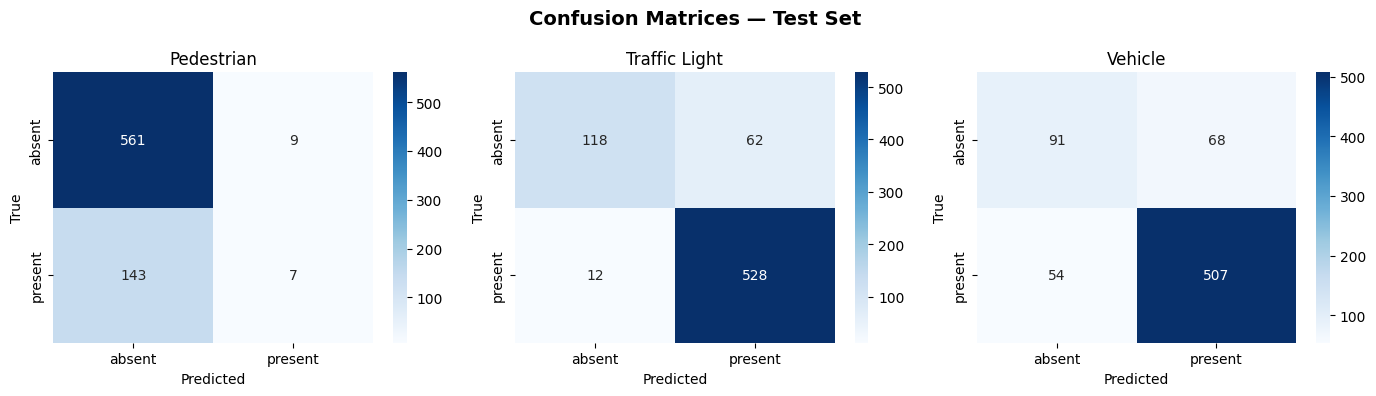

In [27]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')

for ax, task in zip(axes, TASKS):
    _, _, metrics = results[task]
    cm = confusion_matrix(metrics['labels'], metrics['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['absent', 'present'],
                yticklabels=['absent', 'present'])
    ax.set_title(task.replace('has_', '').replace('_', ' ').title())
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(WEIGHTS_DIR, 'confusion_matrices.png'), dpi=120)
plt.show()

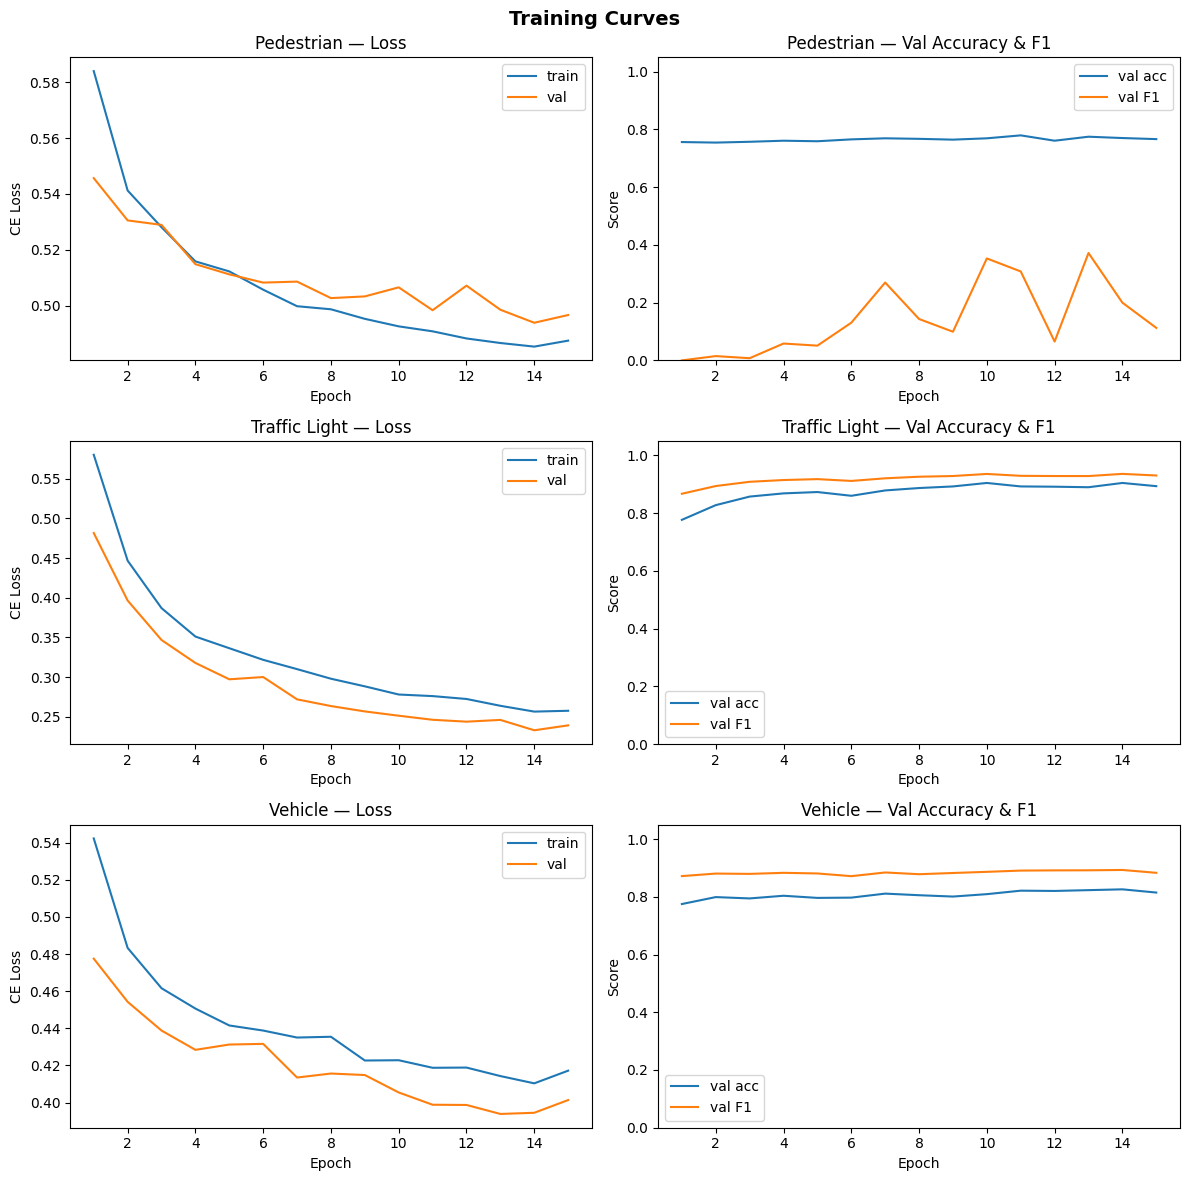

In [28]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle('Training Curves', fontsize=14, fontweight='bold')

epochs = range(1, NUM_EPOCHS + 1)
for row_idx, task in enumerate(TASKS):
    _, history, _ = results[task]
    short_name = task.replace('has_', '').replace('_', ' ').title()

    # Loss
    ax_loss = axes[row_idx, 0]
    ax_loss.plot(epochs, history['train_loss'], label='train')
    ax_loss.plot(epochs, history['val_loss'],   label='val')
    ax_loss.set_title(f'{short_name} — Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('CE Loss')
    ax_loss.legend()
    ax_loss.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # Accuracy / F1
    ax_acc = axes[row_idx, 1]
    ax_acc.plot(epochs, history['val_acc'], label='val acc')
    ax_acc.plot(epochs, history['val_f1'],  label='val F1')
    ax_acc.set_title(f'{short_name} — Val Accuracy & F1')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Score')
    ax_acc.set_ylim(0, 1.05)
    ax_acc.legend()
    ax_acc.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(os.path.join(WEIGHTS_DIR, 'training_curves.png'), dpi=120)
plt.show()

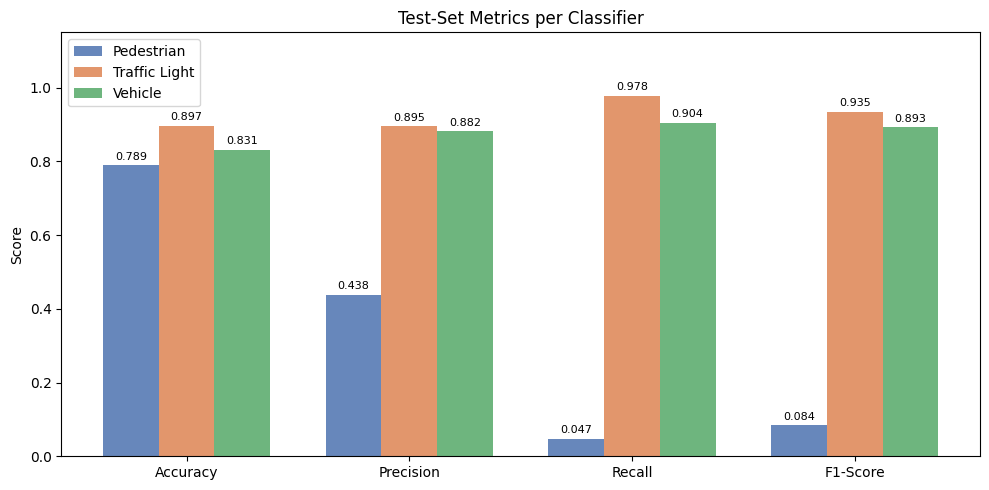

In [29]:
# ── Metric bar chart ──────────────────────────────────────────────────────────
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_keys  = ['accuracy', 'precision', 'recall', 'f1']
task_labels  = [t.replace('has_', '').replace('_', ' ').title() for t in TASKS]

x     = np.arange(len(metric_names))
width = 0.25
colours = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (task, colour) in enumerate(zip(TASKS, colours)):
    _, _, metrics = results[task]
    values = [metrics[k] for k in metric_keys]
    bars = ax.bar(x + i * width, values, width, label=task_labels[i],
                  color=colour, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Test-Set Metrics per Classifier')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(WEIGHTS_DIR, 'metric_comparison.png'), dpi=120)
plt.show()

## 11 — (Optional) Reload a saved model

Use this cell to reload a previously saved full model for inference without retraining.

In [ ]:
def load_classifier(task: str) -> nn.Module:
    """Rebuild the LoRA-ResNet-18 architecture and load saved weights."""
    model      = build_lora_resnet18(task)
    weight_path = os.path.join(WEIGHTS_DIR, f'{task}_full.safetensors')
    state_dict  = load_file(weight_path, device=str(DEVICE))
    model.load_state_dict(state_dict)
    model.eval()
    print(f'Loaded {task} from {weight_path}')
    return model

# Example usage (uncomment to run):
# ped_model = load_classifier('has_pedestrian')

## 12 — (Optional) Single-image inference demo

In [ ]:
@torch.no_grad()
def predict_image(model: nn.Module, image_path: str, task: str):
    """Run inference on a single image and print the result."""
    image  = Image.open(image_path).convert('RGB')
    tensor = eval_transform(image).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
        logits = model(tensor)

    probs      = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    prediction = int(probs.argmax())
    confidence = float(probs[prediction])

    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    ax.imshow(image)
    ax.axis('off')
    label_text = 'PRESENT' if prediction == 1 else 'ABSENT'
    ax.set_title(
        f'{task}\nPrediction: {label_text}  (confidence: {confidence:.1%})',
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

    return prediction, confidence

# Example usage (uncomment and set a real path):
# predict_image(results['has_pedestrian'][0],
#               '/content/drive/MyDrive/carnomaly/dataset/train/0.png',
#               'has_pedestrian')

In [1]:
with open('/content/kprojection.py', 'r') as f:
    print(f.read())

from dataclasses import dataclass
from itertools import combinations, product
from typing import Any, Dict, Iterable, List, Optional, Tuple, TypeVar
from abc import ABC, abstractmethod
from typing import TypeVar

__all__ = ["KCoverageResult", "KProjectionCoverage"]

Self = TypeVar("Self")

class Metric(ABC):
    def __init__(self, *args, **kwargs) -> None:
        pass

    @abstractmethod
    def update(self: Self, *args, **kwargs) -> Self:
        """
        Add values to the metric
        """
        raise NotImplementedError

    @abstractmethod
    def compute(self, *args, **kwargs):
        """
        Compute the metric
        """
        raise NotImplementedError


class Projection:
    """
    A single projection
    """

    def __init__(self, n_values: List[int], names: Optional[List[str]] = None) -> None:
        """
        Holds a subspace with the cartesian product of some dimension and
        monitors coverage for this subspace.

        :param n_values: list with n

In [2]:
from kprojection import KProjectionCoverage, KCoverageResult

# Define the dimensions for k-projection coverage based on the tasks
dimensions = {
    'has_pedestrian': [0, 1], # 0: absent, 1: present
    'has_traffic_light': [0, 1],
    'has_vehicle': [0, 1]
}

# Extract true labels for the test set from the results of each task
# Assuming that the 'labels' in test_metrics correspond to the same samples across tasks
labels_pedestrian = results['has_pedestrian'][2]['labels']
labels_traffic_light = results['has_traffic_light'][2]['labels']
labels_vehicle = results['has_vehicle'][2]['labels']

# Create scenarios from the combined true labels for each test sample
all_test_scenarios = []
num_test_samples = len(labels_pedestrian) # All label arrays should have the same length

for i in range(num_test_samples):
    scenario = {
        'has_pedestrian': int(labels_pedestrian[i]),
        'has_traffic_light': int(labels_traffic_light[i]),
        'has_vehicle': int(labels_vehicle[i])
    }
    all_test_scenarios.append(scenario)

print(f"Total test scenarios created: {len(all_test_scenarios)}")

# Compute k-projection coverage for k=1, 2, and 3
for k_val in [1, 2, 3]:
    print(f"\n--- K-Projection Coverage for k={k_val} ---")
    kpc = KProjectionCoverage(dimensions=dimensions, k=k_val)
    kpc.add_scenarios(all_test_scenarios)
    coverage_result = kpc.compute()
    print(f"Coverage: {coverage_result.coverage:.4f}")
    print(f"Covered points: {coverage_result.covered}")
    print(f"Total points: {coverage_result.total}")
    print(f"Number of scenes (samples): {coverage_result.scenes}")


NameError: name 'results' is not defined